# House-Price Regression with a Neural Network

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
path = "houses.csv"
dataset = pd.read_csv(path)

In [5]:
dataset.drop('Id', inplace=True, axis=1)
dataset[0:15]

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,BedroomAbvGr,TotRmsAbvGrd,SalePrice
0,65.0,8450,7,5,2003,3,8,208500
1,80.0,9600,6,8,1976,3,6,181500
2,68.0,11250,7,5,2001,3,6,223500
3,60.0,9550,7,5,1915,3,7,140000
4,84.0,14260,8,5,2000,4,9,250000
5,85.0,14115,5,5,1993,1,5,143000
6,75.0,10084,8,5,2004,3,7,307000
7,NaN,10382,7,6,1973,3,7,200000
8,51.0,6120,7,5,1931,2,8,129900
9,50.0,7420,5,6,1939,2,5,118000


In [6]:
# Remove rows with missing data
dataset.dropna(axis=0, inplace=True)
dataset[0:15]

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,BedroomAbvGr,TotRmsAbvGrd,SalePrice
0,65.0,8450,7,5,2003,3,8,208500
1,80.0,9600,6,8,1976,3,6,181500
2,68.0,11250,7,5,2001,3,6,223500
3,60.0,9550,7,5,1915,3,7,140000
4,84.0,14260,8,5,2000,4,9,250000
5,85.0,14115,5,5,1993,1,5,143000
6,75.0,10084,8,5,2004,3,7,307000
8,51.0,6120,7,5,1931,2,8,129900
9,50.0,7420,5,6,1939,2,5,118000
10,70.0,11200,5,5,1965,3,5,129500


In [7]:
print(dataset.columns.values)

['LotFrontage' 'LotArea' 'OverallQual' 'OverallCond' 'YearBuilt'
 'BedroomAbvGr' 'TotRmsAbvGrd' 'SalePrice']


In [8]:
y = dataset['SalePrice']

X = dataset.copy()
X.drop('SalePrice', inplace=True, axis=1)

print(y[:5])
print(X[:5])

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64
   LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  BedroomAbvGr  \
0         65.0     8450            7            5       2003             3   
1         80.0     9600            6            8       1976             3   
2         68.0    11250            7            5       2001             3   
3         60.0     9550            7            5       1915             3   
4         84.0    14260            8            5       2000             4   

   TotRmsAbvGrd  
0             8  
1             6  
2             6  
3             7  
4             9  


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size = 0.3,
    random_state=10
)
print(len(dataset))
print(len(X_train))
print(len(X_test))

1201
840
361


In [10]:
# Demonstrate the effect of feature scaling

from sklearn.preprocessing import StandardScaler

print("Original values:")
print(X_train[:2])
print(X_test[:2])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nScaled values:")
print(X_train[:2])
print(X_test[:2])

Original values:
     LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  BedroomAbvGr  \
750         55.0     8800            4            7       1910             3   
542         78.0    10140            7            5       1998             3   

     TotRmsAbvGrd  
750             7  
542             7  
      LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  BedroomAbvGr  \
148          63.0     7500            7            5       2004             3   
1313        108.0    14774            9            5       1999             4   

      TotRmsAbvGrd  
148              6  
1313            10  

Scaled values:
[[-0.59343374 -0.1345642  -1.50163769  1.32077067 -1.94355278  0.17004777
   0.28779232]
 [ 0.33072714  0.01790758  0.61239973 -0.5252316   0.86970448  0.17004777
   0.28779232]]
[[-0.27198648 -0.28248458  0.61239973 -0.5252316   1.06151747  0.17004777
  -0.33687319]
 [ 1.53615437  0.54518683  2.02175801 -0.5252316   0.90167331  1.40142814
   2.16178885]]


In [11]:
model = Sequential(
    [
        Dense(64, activation='relu'),
        Dense(128, activation='relu'),
        Dense(1)
    ])

In [12]:
model.compile(
            loss='mse',
            optimizer=tf.keras.optimizers.Adam(0.001),
            metrics=['mae', 'mse']  # Monitor training and evaluation performance
             ) 

# MAE - Mean Absolute Error
# MAE = (1/n) * Σ|actual - predicted|

# MSE - Mean Squared Error
# MSE = (1/n) * Σ(actual - predicted)^2

In [13]:
model.fit(
    X_train, y_train, 
    epochs=50,
    batch_size=32 # Training examples processed in each forward/backward pass
)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 41892294656.0000 - mae: 183276.1094 - mse: 41892294656.0000
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41448087552.0000 - mae: 182918.6875 - mse: 41448087552.0000
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39977951232.0000 - mae: 180500.9688 - mse: 39977951232.0000
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 39607291904.0000 - mae: 181286.8438 - mse: 39607291904.0000 
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 40918818816.0000 - mae: 183304.9219 - mse: 40918818816.0000
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 41080270848.0000 - mae: 184736.9219 - mse: 41080270848.0000
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 44352208896.0000 - mae: 189479.8750 - mse: 44352208896.0000
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 42189139968.0000 - mae: 184259.6250 - mse: 42189139968.0000
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,885 (105.02 KB)

 Trainable params: 8,961 (35.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,924 (70.02 KB)

In [16]:
predictions = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [17]:
from sklearn.metrics import mean_squared_error

# The root mean squared error (RMSE)
print("Root mean squared error: %.2f"
      % np.sqrt(mean_squared_error(y_test, predictions)))

Root mean squared error: 96501.68


In [18]:
print("predictions = \n", predictions[0:10])
print("\ncurrents = \n",y_test[0:10])

predictions = 
 [[110290.78 ]
 [339560.03 ]
 [ 38619.223]
 [ 57785.438]
 [ 99285.05 ]
 [ 39406.938]
 [ 59633.586]
 [ 63371.707]
 [ 49530.926]
 [195202.94 ]]

currents = 
 148     141000
1313    333168
1252    130000
513     134000
920     201000
609     118500
583     325000
79      110000
1125    115000
700     312500
Name: SalePrice, dtype: int64


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


[]

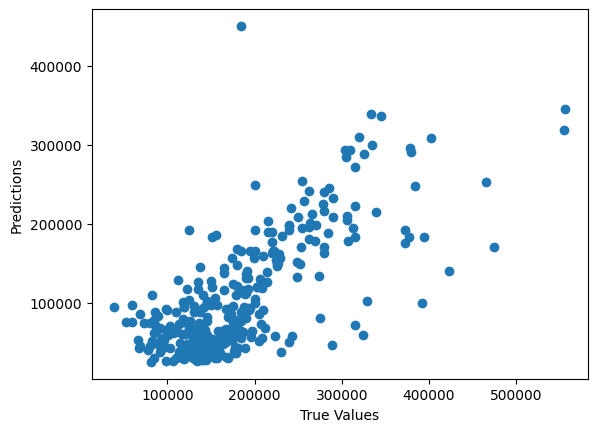

In [19]:
test_predictions = model.predict(X_test).flatten()
plt.scatter(y_test, test_predictions)
plt.xlabel('True Values')
plt.ylabel('Predictions')

plt.plot()

[]

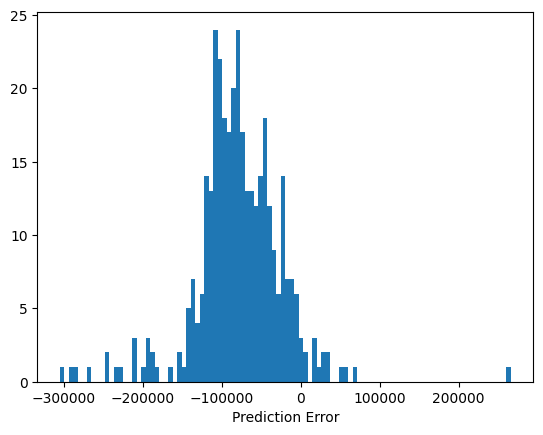

In [20]:
error = test_predictions - y_test
plt.hist(error, bins = 100)
plt.xlabel("Prediction Error")
plt.plot()